In [8]:
import pickle
import pandas as pd
import numpy as np
from scipy.sparse import load_npz
from pathlib import Path
import gc

BASE = Path.cwd().parent

# 加载矩阵和映射
user_item_matrix = load_npz(BASE / 'user_item_matrix.npz')
buy_mask_matrix  = load_npz(BASE / 'buy_mask_matrix.npz')

with open(BASE / 'artifacts_small.pkl', 'rb') as f:
    artifacts = pickle.load(f)

user2idx     = artifacts['user2idx']
idx2user     = artifacts['idx2user']
cat2idx      = artifacts['cat2idx']
idx2cat      = artifacts['idx2cat']
test_gt      = artifacts['test_gt']
user_cluster = artifacts['user_cluster']
cat_rules    = artifacts['cat_rules']
cluster_rules = artifacts['cluster_rules']

# ALS 推荐结果（Step 3 保存的）
with open(BASE / 'recommendation_artifacts.pkl', 'rb') as f:
    arts = pickle.load(f)
als_recs = arts['als_recs']

# 品类内商品热度表
cat_item_pop = pd.read_csv(
    BASE / 'category_item_popularity.csv',
    dtype={
        'category_id':    'int32',
        'item_id':        'int32',
        'buy_cnt':        'int32',
        'cart_cnt':       'int32',
        'pv_cnt':         'int32',
        'unique_users':   'int32',
        'popularity_score': 'int32'
    }
)

# 聚类标签中文名
cluster_names = {
    0: '纯浏览型',
    1: '高价值活跃型',
    2: '收藏研究型',
    3: '加车犹豫型',
    4: '冲动直购型',
    5: '普通活跃型'
}  # ← 按你实际的聚类含义修改

print(f'ALS 推荐用户数        ：{len(als_recs):,}')
print(f'品类内商品热度表行数   ：{len(cat_item_pop):,}')
print(f'涉及品类数            ：{cat_item_pop["category_id"].nunique():,}')
print(f'涉及商品数            ：{cat_item_pop["item_id"].nunique():,}')

ALS 推荐用户数        ：393,391
品类内商品热度表行数   ：3,962,228
涉及品类数            ：9,377
涉及商品数            ：3,960,966


In [9]:
# 每个品类下按热度排好序的商品列表，后续直接查字典，不用每次重新排序
TOP_ITEMS_PER_CAT = 10   # 每个品类保留 Top N 商品备用

cat_top_items = (
    cat_item_pop.sort_values('popularity_score', ascending=False)
                .groupby('category_id')['item_id']
                .apply(lambda x: x.tolist()[:TOP_ITEMS_PER_CAT])
                .to_dict()
)

print(f'有商品索引的品类数：{len(cat_top_items):,}')

# 检查 ALS 推荐的品类有多少能找到对应商品
sample_uid   = list(als_recs.keys())[0]
sample_cats  = als_recs[sample_uid][:5]
covered      = sum(1 for c in sample_cats if c in cat_top_items)
print(f'示例用户前5推荐品类中有商品记录的：{covered} / 5')

有商品索引的品类数：9,377
示例用户前5推荐品类中有商品记录的：5 / 5


In [10]:
def get_final_recommendations(
    uid,
    als_recs,
    cat_top_items,
    cluster_rules,
    user_cluster,
    buy_mask_matrix,
    user2idx,
    cat2idx,
    idx2cat,
    top_k_cats=5,      # 取前 N 个推荐品类
    top_n_items=3,     # 每个品类取前 N 个商品
    rule_top_k=3       # 关联规则补充推荐品类数
):
    """
    两阶段推荐 + 关联规则融合
    返回：{
        'cluster': 簇ID,
        'cluster_name': 簇名称,
        'recommended_cats': [(category_id, [item_id, ...]), ...],
        'rule_supplement': [(antecedent, consequent, lift), ...]
    }
    """
    if uid not in user2idx:
        return None

    u_idx    = user2idx[uid]
    cluster  = int(user_cluster[user_cluster['user_id'] == uid]['cluster'].values[0])

    # ── 第一阶段：ALS 推荐的 Top 品类 ──
    rec_cats = als_recs.get(uid, [])[:top_k_cats]

    # ── 第二阶段：每个品类内取 Top 商品 ──
    recommended_cats = []
    for cat in rec_cats:
        items = cat_top_items.get(cat, [])[:top_n_items]
        recommended_cats.append((cat, items))

    # ── 关联规则补充：基于推荐品类找关联品类 ──
    rules = cluster_rules.get(cluster, cat_rules)   # 优先用簇规则，没有则用全局规则
    rule_supplement = []

    if len(rules) > 0:
        # 已推荐品类作为 antecedent，找高 Lift 的 consequent
        already_rec = set(rec_cats)
        buy_mask    = buy_mask_matrix[u_idx].toarray().flatten()
        bought_cats = {idx2cat[i] for i in np.where(buy_mask > 0)[0]}

        for cat in rec_cats:
            matches = rules[rules['antecedent'] == cat].head(rule_top_k)
            for _, row in matches.iterrows():
                conseq = row['consequent']
                # 不推荐已推荐过的和已买过的
                if conseq not in already_rec and conseq not in bought_cats:
                    rule_supplement.append((cat, conseq, round(row['lift'], 2)))
                    already_rec.add(conseq)

    return {
        'uid':              uid,
        'cluster':          cluster,
        'cluster_name':     cluster_names.get(cluster, f'簇{cluster}'),
        'recommended_cats': recommended_cats,
        'rule_supplement':  rule_supplement
    }

print('推荐函数定义完成')

推荐函数定义完成


In [11]:
FINAL_TOP_K_CATS  = 5
FINAL_TOP_N_ITEMS = 3
FINAL_RULE_TOP_K  = 3

final_recs = {}
all_uids   = list(als_recs.keys())

print(f'为 {len(all_uids):,} 个用户生成最终推荐...')

for i, uid in enumerate(all_uids):
    result = get_final_recommendations(
        uid               = uid,
        als_recs          = als_recs,
        cat_top_items     = cat_top_items,
        cluster_rules     = cluster_rules,
        user_cluster      = user_cluster,
        buy_mask_matrix   = buy_mask_matrix,
        user2idx          = user2idx,
        cat2idx           = cat2idx,
        idx2cat           = idx2cat,
        top_k_cats        = FINAL_TOP_K_CATS,
        top_n_items       = FINAL_TOP_N_ITEMS,
        rule_top_k        = FINAL_RULE_TOP_K
    )
    if result:
        final_recs[uid] = result

    if i % 100000 == 0:
        print(f'  进度：{i:,} / {len(all_uids):,}')

print(f'\n✅ 最终推荐生成完成，覆盖用户数：{len(final_recs):,}')

为 393,391 个用户生成最终推荐...
  进度：0 / 393,391
  进度：100,000 / 393,391
  进度：200,000 / 393,391
  进度：300,000 / 393,391

✅ 最终推荐生成完成，覆盖用户数：393,391


In [12]:
print('=' * 60)
print('推荐结果示例（每簇随机抽取1个用户）')
print('=' * 60)

for cluster_id in sorted(cluster_names.keys()):
    # 找该簇的测试用户
    cluster_uids = [
        uid for uid, rec in final_recs.items()
        if rec['cluster'] == cluster_id
    ]
    if len(cluster_uids) == 0:
        continue

    # 随机取1个
    sample_uid = np.random.choice(cluster_uids)
    rec        = final_recs[sample_uid]

    print(f'\n── 用户 {sample_uid}（{rec["cluster_name"]}）──')
    print(f'  推荐品类 + 商品：')
    for cat, items in rec['recommended_cats']:
        item_str = ', '.join(str(i) for i in items) if items else '无商品数据'
        print(f'    品类 {cat} → 商品 [{item_str}]')

    if rec['rule_supplement']:
        print(f'  关联规则补充推荐：')
        for ant, con, lift in rec['rule_supplement']:
            print(f'    买了品类 {ant} → 推荐品类 {con}（Lift={lift}）')
    else:
        print(f'  关联规则补充：无匹配规则')

推荐结果示例（每簇随机抽取1个用户）

── 用户 594628（纯浏览型）──
  推荐品类 + 商品：
    品类 1471163 → 商品 [1635656, 3325793, 4506512]
    品类 4756105 → 商品 [812879, 4211339, 4649427]
    品类 4145813 → 商品 [2828948, 232919, 3114069]
    品类 4643350 → 商品 [602041, 3000506, 3504111]
    品类 3607361 → 商品 [3845720, 2331370, 138964]
  关联规则补充推荐：
    买了品类 4145813 → 推荐品类 3002561.0（Lift=11.25）

── 用户 731266（高价值活跃型）──
  推荐品类 + 商品：
    品类 1074254 → 商品 [1595279, 4063028, 1092652]
    品类 3158249 → 商品 [2790543, 705557, 1044710]
    品类 4758477 → 商品 [3497027, 1334594, 4272899]
    品类 3422001 → 商品 [693361, 4664336, 3228185]
    品类 1936748 → 商品 [1044905, 65043, 4685098]
  关联规则补充：无匹配规则

── 用户 641195（收藏研究型）──
  推荐品类 + 商品：
    品类 4170419 → 商品 [259923, 1234236, 2691816]
    品类 1879194 → 商品 [3034696, 3565922, 1762997]
    品类 2096639 → 商品 [2167765, 2236861, 1773536]
    品类 154040 → 商品 [1699547, 3794565, 4074805]
    品类 2885642 → 商品 [4551433, 1624042, 3405783]
  关联规则补充推荐：
    买了品类 2885642 → 推荐品类 4159072.0（Lift=4.54）

── 用户 350161（加车犹豫型）──
  推荐品类 + 商

── 各簇推荐覆盖情况 ──
   簇名称  推荐用户数  有关联规则补充    规则覆盖率
  纯浏览型    913      383 0.419496
高价值活跃型  64696    35853 0.554176
 收藏研究型  64362    17728 0.275442
 加车犹豫型  35950     4242 0.117997
 冲动直购型  53678    24572 0.457767
 普通活跃型 173792    53047 0.305233


C:\Users\xxxxx\AppData\Local\Temp\ipykernel_2756\1058334219.py:51: UserWarning: Glyph 32431 (\N{CJK UNIFIED IDEOGRAPH-7EAF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xxxxx\AppData\Local\Temp\ipykernel_2756\1058334219.py:51: UserWarning: Glyph 27983 (\N{CJK UNIFIED IDEOGRAPH-6D4F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xxxxx\AppData\Local\Temp\ipykernel_2756\1058334219.py:51: UserWarning: Glyph 35272 (\N{CJK UNIFIED IDEOGRAPH-89C8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xxxxx\AppData\Local\Temp\ipykernel_2756\1058334219.py:51: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xxxxx\AppData\Local\Temp\ipykernel_2756\1058334219.py:51: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xxxxx\AppData\Local\Temp\ipykernel_2756\1058334219.py:51: UserWarning: Glyph 20215 (\N{CJK 

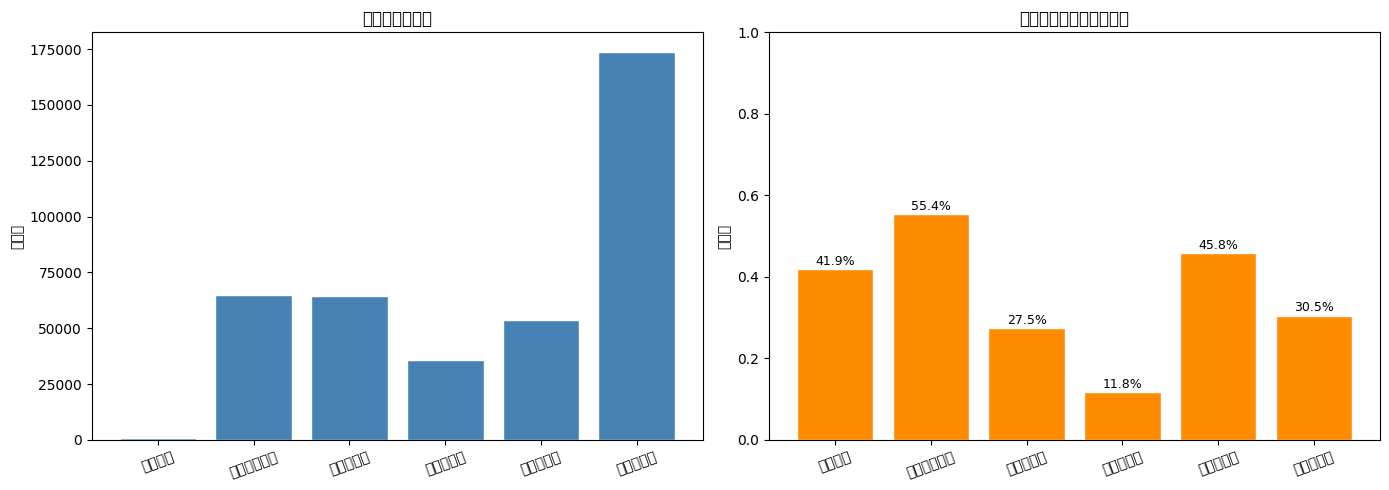

In [13]:
import matplotlib.pyplot as plt

# 统计各簇推荐覆盖情况
cluster_stats = []
for cluster_id, cname in cluster_names.items():
    cluster_uids = [uid for uid, rec in final_recs.items()
                    if rec['cluster'] == cluster_id]
    # 有关联规则补充的用户比例
    rule_covered = sum(
        1 for uid in cluster_uids
        if len(final_recs[uid]['rule_supplement']) > 0
    )
    cluster_stats.append({
        'cluster':      cluster_id,
        'name':         cname,
        'total':        len(cluster_uids),
        'rule_covered': rule_covered,
        'rule_rate':    rule_covered / len(cluster_uids) if cluster_uids else 0
    })

stats_df = pd.DataFrame(cluster_stats)
print('── 各簇推荐覆盖情况 ──')
print(stats_df[['name','total','rule_covered','rule_rate']]
      .rename(columns={
          'name':'簇名称',
          'total':'推荐用户数',
          'rule_covered':'有关联规则补充',
          'rule_rate':'规则覆盖率'
      }).to_string(index=False))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各簇推荐用户数
axes[0].bar(stats_df['name'], stats_df['total'],
            color='steelblue', edgecolor='white')
axes[0].set_title('各簇推荐用户数')
axes[0].set_ylabel('用户数')
axes[0].tick_params(axis='x', rotation=20)

# 右图：关联规则覆盖率
axes[1].bar(stats_df['name'], stats_df['rule_rate'],
            color='darkorange', edgecolor='white')
axes[1].set_title('各簇关联规则补充覆盖率')
axes[1].set_ylabel('覆盖率')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(stats_df['rule_rate']):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# final_recs 体积可能较大，转成 DataFrame 格式保存更通用
rows = []
for uid, rec in final_recs.items():
    for rank, (cat, items) in enumerate(rec['recommended_cats'], 1):
        rows.append({
            'user_id':     uid,
            'cluster':     rec['cluster'],
            'cluster_name': rec['cluster_name'],
            'rank':        rank,
            'category_id': cat,
            'top_items':   ','.join(str(i) for i in items)
        })

final_df = pd.DataFrame(rows)
final_df.to_csv(BASE / 'final_recommendations.csv', index=False)

# 关联规则补充单独保存
rule_rows = []
for uid, rec in final_recs.items():
    for ant, con, lift in rec['rule_supplement']:
        rule_rows.append({
            'user_id':       uid,
            'cluster':       rec['cluster'],
            'antecedent_cat': ant,
            'consequent_cat': con,
            'lift':          lift
        })

rule_df = pd.DataFrame(rule_rows)
rule_df.to_csv(BASE / 'final_rule_supplement.csv', index=False)

print('✅ Step 4 完成')
print(f'  final_recommendations.csv  ：{len(final_df):,} 行')
print(f'  final_rule_supplement.csv  ：{len(rule_df):,} 行')
print(f'  覆盖用户数                 ：{final_df["user_id"].nunique():,}')
print()
print('── 输出文件说明 ──')
print('  final_recommendations.csv：每个用户的推荐品类 + 品类内Top商品')
print('  final_rule_supplement.csv：基于关联规则的补充推荐品类')

✅ Step 5 完成
  final_recommendations.csv  ：1,966,955 行
  final_rule_supplement.csv  ：256,253 行
  覆盖用户数                 ：393,391

── 输出文件说明 ──
  final_recommendations.csv：每个用户的推荐品类 + 品类内Top商品
  final_rule_supplement.csv：基于关联规则的补充推荐品类
